## Instanciando a base

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)

from src.config import DADOS_LIMPOS
from src.models import RANDOM_STATE

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
X = df.drop(columns=['diagnosis'])

y = df['diagnosis']

In [4]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

In [5]:
#vamos aplicar um label encoder para transformar os valores de target em numero antes de passar para o modelo

le = LabelEncoder()

y = le.fit_transform(y)

y[:25]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [6]:
le.classes_

array(['B', 'M'], dtype=object)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.25, stratify=y)

O parâmetro `stratify` é utilizado para garantir que a divisão entre treino e teste preserve a distribuição original da variável alvo. Em bases desbalanceadas, onde uma classe é mais frequente que a outra, sua utilização evita que uma das partições fique com proporções distorcidas.

Ao informar `stratify=target` no `train_test_split`, o algoritmo realiza uma amostragem estratificada, mantendo aproximadamente a mesma proporção de classes presente no conjunto completo tanto no conjunto de treino quanto no de teste. Isso assegura maior representatividade estatística e reduz o risco de viés na avaliação do modelo.

A gente pode conferir isso com o numpy

In [8]:
np.bincount(y_train) / len(y_train)

array([0.62676056, 0.37323944])

In [9]:
np.bincount(y_test) / len(y_test)

array([0.62937063, 0.37062937])

Basicamente a mesma proporção dos valores visto na análise exploratória.

## Treinando a base

In [10]:
clf = Perceptron()

clf.fit(X_train, y_train)

Perceptron()

In [11]:
y_pred = clf.predict(X_test)

In [12]:
clf.score(X_test, y_test)

0.9020979020979021

In [13]:
accuracy_score(y_test, y_pred)

0.9020979020979021

Estamos analisando a acurácia do modelo, porém, em problemas de classificação, essa métrica nem sempre é a mais adequada. Em cenários com desbalanceamento da variável alvo, a acurácia pode gerar uma interpretação equivocada do desempenho.

Mesmo utilizando estratégias como estratificação ou técnicas de balanceamento, é fundamental avaliar métricas adicionais.

Além disso, em bases da área da saúde é essencial analisar a natureza dos erros do modelo, e não apenas métricas agregadas. Nesses contextos, o tipo de erro possui impacto clínico direto.

Nossa base, no qual a classe M representa casos malignos e B casos benignos, um falso negativo — isto é, classificar um caso maligno como benigno — é particularmente crítico. Esse erro pode atrasar diagnóstico e tratamento, gerando consequências graves para o paciente.

## Métricas

### Matriz de confusão

In [14]:
le.classes_

array(['B', 'M'], dtype=object)

In [15]:
np.bincount(y_test)

array([90, 53], dtype=int64)

In [16]:
confusion_matrix(y_test, y_pred)

array([[89,  1],
       [13, 40]], dtype=int64)

Ou seja dos 90 que são B ele previu 89 como B 
E dos 53 que são M ele previu 40 como M

Na tabela a seguir fica mais fácil de ver isso

In [17]:
cm = confusion_matrix(y_test, y_pred)

tabela = pd.DataFrame(cm,index=["Eram B","Eram M"],columns=["Modelo previu B","Modelo previu M"])

tabela

,Modelo previu B,Modelo previu M
Eram B,89,1
Eram M,13,40


In [18]:
#matriz normalizada - porcentagem total
confusion_matrix(y_test, y_pred, normalize='all')

array([[0.62237762, 0.00699301],
       [0.09090909, 0.27972028]])

In [19]:
#matriz normalizada - porcentagem por classes
confusion_matrix(y_test, y_pred, normalize='true')

array([[0.98888889, 0.01111111],
       [0.24528302, 0.75471698]])

In [20]:
#matriz normalizada - porcentagem por previsões
confusion_matrix(y_test, y_pred, normalize='pred')

array([[0.87254902, 0.02439024],
       [0.12745098, 0.97560976]])

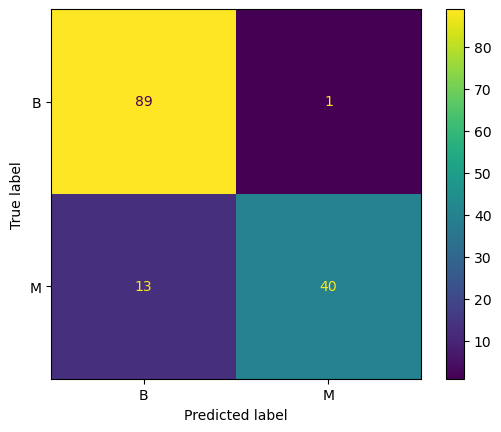

In [21]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot()

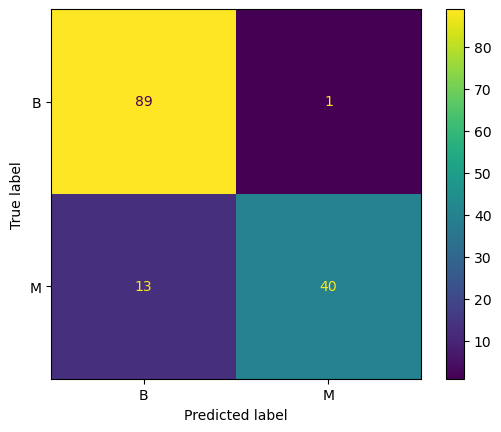

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)

### Recall

Recall (também chamado **sensibilidade** ou *true positive rate*) mede a capacidade do modelo de identificar corretamente os casos positivos.

Definição objetiva:

Recall = VP / (VP + FN)

Onde:

* VP = verdadeiros positivos
* FN = falsos negativos

Interpretação:
Entre todos os casos que realmente são positivos, qual proporção o modelo conseguiu detectar corretamente.

Exemplo usando sua classe **M** como positiva:

VP = 40
FN = 13

Recall = 40 / (40 + 13) ≈ 0,755

Ou seja, o modelo identificou corretamente cerca de 75,5% dos casos M reais.

Em resumo: recall mede o quanto o modelo deixa de “perder” casos positivos.


In [23]:
recall_score(y_test, y_pred)

0.7547169811320755

### Precision

Precision (também chamada **valor preditivo positivo**) mede a confiabilidade das previsões positivas do modelo.

Definição:

Precision = VP / (VP + FP)

Onde:

* VP = verdadeiros positivos
* FP = falsos positivos

Interpretação:
Entre todos os casos que o modelo previu como positivos, qual proporção realmente era positiva.

Usando sua classe **M** como positiva:

VP = 40
FP = 1

Precision = 40 / (40 + 1) ≈ 0,976

Ou seja, quando o modelo prevê M, ele está correto em aproximadamente 97,6% das vezes.

Em resumo: precision mede o quanto o modelo “acerta quando diz que é positivo”.


In [24]:
precision_score(y_test, y_pred)

0.975609756097561

### F Score

F-score (ou **F1-score**) é a média harmônica entre precision e recall. Ele equilibra as duas métricas em um único valor.

Definição:

F1 = 2 * (Precision * Recall) / (Precision + Recall)

Ele é útil quando você precisa balancear:

* não perder positivos (alto recall)
* não gerar muitos falsos positivos (alta precision)

Usando seus valores para a classe **M**:

Precision ≈ 0,976
Recall ≈ 0,755

F1 ≈ 2 * (0,976 * 0,755) / (0,976 + 0,755)
F1 ≈ 0,852

Interpretação: o modelo tem um bom equilíbrio entre detectar casos M e não errar quando prevê M.

Resumo: o F1 penaliza modelos que têm precision alta e recall baixo (ou vice-versa). Ele só será alto se ambos forem altos.


In [25]:
f1_score(y_test, y_pred)

0.851063829787234

### Curva ROC

A curva ROC (Receiver Operating Characteristic) avalia o desempenho de um classificador binário para todos os possíveis limiares de decisão.

Ela relaciona:

* Eixo Y → TPR (True Positive Rate) = Recall = VP / (VP + FN)
* Eixo X → FPR (False Positive Rate) = FP / (FP + VN)

Interpretação técnica:

Cada ponto da curva representa um threshold diferente usado para converter probabilidades em classe.
À medida que você diminui o limiar, o recall tende a aumentar, mas o FPR também aumenta.

Extremos:

* Canto inferior esquerdo (0,0): modelo muito conservador (quase nada é previsto como positivo)
* Canto superior direito (1,1): tudo previsto como positivo
* Canto superior esquerdo (0,1): classificador perfeito

A métrica associada é o AUC (Area Under the Curve):

* AUC = 1 → modelo perfeito
* AUC = 0.5 → equivalente ao acaso
* AUC < 0.5 → pior que aleatório

Resumo objetivo:
A curva ROC mostra a capacidade do modelo de separar as duas classes independentemente de um threshold específico. O AUC quantifica essa capacidade.


In [26]:
roc_auc = roc_auc_score(y_test, y_pred)
roc_auc

0.8718029350104822

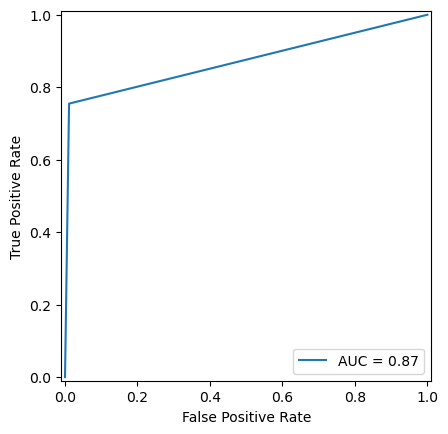

In [27]:
fpr, tpr, limeares = roc_curve(y_test, y_pred)

disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)

disp.plot()

### Curva Precision-Recall

A curva Precision-Recall (PR) mostra a relação entre **precision** e **recall** para todos os possíveis limiares de decisão de um classificador binário.

Definições envolvidas:

* Recall = VP / (VP + FN)
* Precision = VP / (VP + FP)

Construção:

Para cada threshold aplicado às probabilidades do modelo:

* calcula-se o recall
* calcula-se a precision
* plota-se um ponto (Recall no eixo X, Precision no eixo Y)

Interpretação técnica:

À medida que você reduz o threshold:

* o recall tende a aumentar (mais positivos detectados)
* a precision tende a diminuir (mais falsos positivos)

A métrica associada é o **AUPRC** (Area Under the Precision-Recall Curve).

Pontos importantes:

* É mais informativa que ROC quando há **desbalanceamento de classes**.
* Foca diretamente na qualidade da classe positiva.
* O baseline da curva não é 0.5 (como na ROC), mas sim a proporção da classe positiva no dataset.

Comparação conceitual:

* ROC mede separabilidade global entre classes.
* Precision-Recall mede desempenho específico na classe positiva, penalizando fortemente falsos positivos.

Resumo objetivo:
A curva Precision-Recall mostra o trade-off entre detectar o máximo de positivos e manter alta confiabilidade nas previsões positivas, sendo especialmente adequada para problemas com classes raras.


In [28]:
average_precision = average_precision_score(y_test, y_pred)
average_precision

0.8272183407940426

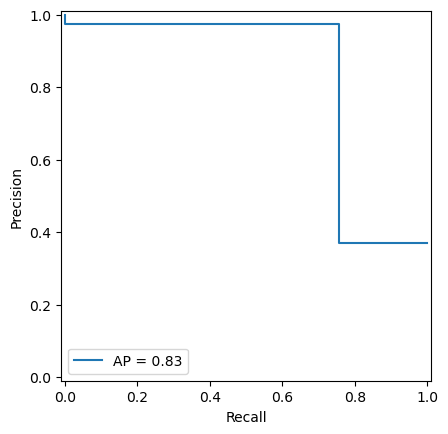

In [29]:
precision, recall, limeares = precision_recall_curve(y_test, y_pred)

disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision)

disp.plot()

### Classification Report

In [30]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           B       0.87      0.99      0.93        90
           M       0.98      0.75      0.85        53

    accuracy                           0.90       143
   macro avg       0.92      0.87      0.89       143
weighted avg       0.91      0.90      0.90       143



## Resumo da situação

In [31]:
cm = confusion_matrix(y_test, y_pred)

tabela = pd.DataFrame(cm,index=["Eram B","Eram M"],columns=["Modelo previu B","Modelo previu M"])

tabela

,Modelo previu B,Modelo previu M
Eram B,89,1
Eram M,13,40


Conforme observado na tabela e corroborado pelas métricas calculadas, o modelo apresenta desempenho superior na classificação dos casos da classe **B**. Para a classe **M**, entretanto, o desempenho é inferior, com recall de aproximadamente 75%, indicando que cerca de 25% dos casos M reais não estão sendo corretamente identificados.

Essa diferença pode estar associada ao desbalanceamento na quantidade de registros entre as classes. Mesmo com a aplicação de técnicas adequadas durante o `train_test_split`, a menor representatividade da classe M pode ter impactado a capacidade do modelo de aprender seus padrões com a mesma eficácia.
